# Sentiment Analysis Using Tensorflow (NLP Transfer Learning)

Working versions:
- TensorFlow 2.15.0
- TensorFlow Datasets 4.9.2
- NumPy 1.26.x
- Protobuf 4.23.4

#### Setup and imports

In [20]:
import os
import numpy as np
import tensorflow as tf
import os, random, re, json
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pickle

# For reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


#### Parameters and paths 

In [21]:
GLOVE_PATH = "glove.6B.100d.txt"
EMBED_DIM = 100
MAX_WORDS = 20000
MAX_LEN = 120
BATCH_SIZE = 64
EPOCHS = 20
NUM_CLASSES = 4

print("Parameters initialized.")

Parameters initialized.


#### Load Dataset

In [22]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Dataset path:", path)

df = pd.read_csv(os.path.join(path, "twitter_training.csv"), header=None,
                 names=["ID", "Entity", "Sentiment", "Text"])
df = df[['Text', 'Sentiment']].dropna()
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].str.strip()

print(f"Loaded {len(df)} samples")
df.head()

Dataset path: C:\Users\user\.cache\kagglehub\datasets\jp797498e\twitter-entity-sentiment-analysis\versions\2
Loaded 73996 samples


,Text,Sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


In [23]:
# Number of samples per sentiment class
class_counts = df['Sentiment'].value_counts()

print(class_counts)

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


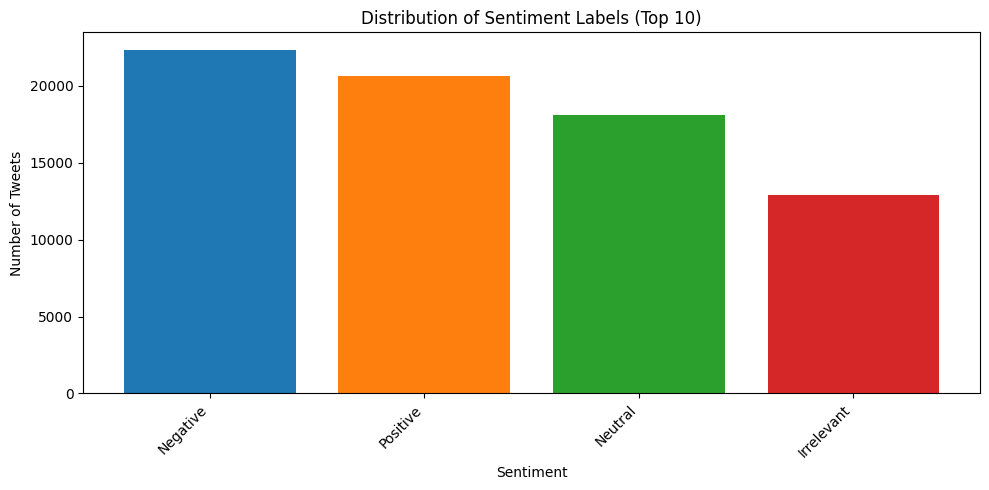

In [24]:
import matplotlib.pyplot as plt

label_counts = df['Sentiment'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color=plt.cm.tab10.colors[:len(label_counts)])
plt.title('Distribution of Sentiment Labels (Top 10)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Preprocessing & Split

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} = {cls}")

# Split: 70% train, 15% val, 15% test
texts = df['Text'].tolist()
labels = df['label'].tolist()

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"\nTrain: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")


Label mapping:
  0 = Irrelevant
  1 = Negative
  2 = Neutral
  3 = Positive

Train: 51797, Val: 11099, Test: 11100


### Tokenization and Padding

In [26]:
from sklearn.model_selection import train_test_split

# Clean whitespace from columns
df['Text'] = df['Text'].str.strip()
df['Sentiment'] = df['Sentiment'].str.strip()

# Define negative sentiments — everything else maps to positive (1)
negative_sentiments = {
    'Negative', 'Sadness', 'Anger', 'Fear', 'Disgust', 'Frustration',
    'Anxiety', 'Disappointment', 'Loneliness', 'Grief', 'Boredom',
    'Jealousy', 'Shame', 'Embarrassment', 'Confusion', 'Apathy',
    'Despair', 'Regret', 'Resentment', 'Pessimism', 'Melancholy',
    'Hostility', 'Guilt', 'Insecurity', 'Overwhelmed', 'Vulnerability',
    'Helplessness', 'Numbness', 'Distrust', 'Bitterness', 'Alienation',
    'Isolation', 'Paranoia', 'Envy', 'Cynicism', 'Agitation',
}

# Map to binary labels: 1 = positive, 0 = negative
df['label'] = df['Sentiment'].apply(lambda x: 0 if x in negative_sentiments else 1)

print(f"Dataset size: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}")

# Split into train (70%), val (15%), test (15%)
texts = df['Text'].tolist()
labels = df['label'].tolist()

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"\nTrain: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")


Dataset size: 73996
Label distribution:
label
1    51638
0    22358
Name: count, dtype: int64

Train: 51797, Val: 11099, Test: 11100


In [27]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

def texts_to_padded(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = texts_to_padded(train_texts)
X_val = texts_to_padded(val_texts)
X_test = texts_to_padded(test_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

print(f"Tokenization complete. Shapes: X_train={X_train.shape}, y_train={y_train.shape}")

Tokenization complete. Shapes: X_train=(51797, 120), y_train=(51797,)


### GloVe Embeddings

In [28]:
import zipfile, os, requests

url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"

if not os.path.exists("glove.6B.100d.txt"):
    print("Downloading GloVe embeddings (862MB)... please wait 1–3 minutes.")
    r = requests.get(url, stream=True)
    with open(glove_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)
    print("Extracting GloVe files...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Done!")
else:
    print("GloVe file already exists.")

GloVe file already exists.


In [29]:
def load_glove_embeddings(glove_path, word_index, embed_dim=100, max_words=20000):
    embeddings_index = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word = parts[0]
            coefs = np.asarray(parts[1:], dtype='float32')
            embeddings_index[word] = coefs

    print(f"Loaded {len(embeddings_index):,} GloVe word vectors.")

    num_words = min(max_words, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embed_dim))
    for word, i in word_index.items():
        if i < num_words:
            vec = embeddings_index.get(word)
            if vec is not None:
                embedding_matrix[i] = vec
    return embedding_matrix

embedding_matrix = load_glove_embeddings(GLOVE_PATH, tokenizer.word_index, EMBED_DIM, MAX_WORDS)

Loaded 400,000 GloVe word vectors.


### Build Model

In [30]:
from tensorflow.keras import layers, models, optimizers, callbacks

def build_model(num_words, embed_dim, max_len, num_classes, embedding_matrix=None):
    inp = layers.Input(shape=(max_len,))
    if embedding_matrix is not None:
        emb = layers.Embedding(
            input_dim=num_words,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=False,
            input_length=max_len
        )(inp)
    else:
        emb = layers.Embedding(num_words, embed_dim, input_length=max_len)(inp)
    
    x = layers.Bidirectional(layers.LSTM(64))(emb)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

num_words = min(MAX_WORDS, len(tokenizer.word_index) + 1)
model = build_model(num_words, EMBED_DIM, MAX_LEN, NUM_CLASSES, embedding_matrix)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 120)]             0         
                                                                 
 embedding_2 (Embedding)     (None, 120, 100)          2000000   
                                                                 
 bidirectional_2 (Bidirecti  (None, 128)               84480     
 onal)                                                           
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                           

### Train Model

In [31]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=2
)

print("Training complete.")

Epoch 1/20
810/810 - 244s - loss: 0.5277 - accuracy: 0.7364 - val_loss: 0.4603 - val_accuracy: 0.7698 - 244s/epoch - 302ms/step
Epoch 2/20
810/810 - 299s - loss: 0.4533 - accuracy: 0.7806 - val_loss: 0.4328 - val_accuracy: 0.7913 - 299s/epoch - 369ms/step
Epoch 3/20
810/810 - 76s - loss: 0.4207 - accuracy: 0.7989 - val_loss: 0.4155 - val_accuracy: 0.8029 - 76s/epoch - 93ms/step
Epoch 4/20
810/810 - 69s - loss: 0.3876 - accuracy: 0.8175 - val_loss: 0.3881 - val_accuracy: 0.8176 - 69s/epoch - 86ms/step
Epoch 5/20
810/810 - 306s - loss: 0.3572 - accuracy: 0.8345 - val_loss: 0.3726 - val_accuracy: 0.8296 - 306s/epoch - 378ms/step
Epoch 6/20
810/810 - 171s - loss: 0.3258 - accuracy: 0.8518 - val_loss: 0.3485 - val_accuracy: 0.8458 - 171s/epoch - 211ms/step
Epoch 7/20
810/810 - 67s - loss: 0.2940 - accuracy: 0.8700 - val_loss: 0.3318 - val_accuracy: 0.8551 - 67s/epoch - 82ms/step
Epoch 8/20
810/810 - 67s - loss: 0.2680 - accuracy: 0.8830 - val_loss: 0.3141 - val_accuracy: 0.8658 - 67s/epoch 

### Evaluate Model and Check Calibration

In [36]:
from sklearn.preprocessing import LabelEncoder

# Encode 4 sentiment classes to integers
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} = {cls}")

# Split: 70% train, 15% val, 15% test
texts = df['Text'].tolist()
labels = df['label'].tolist()

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"\nTrain: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Label mapping:
  0 = Irrelevant
  1 = Negative
  2 = Neutral
  3 = Positive

Train: 51797, Val: 11099, Test: 11100


### Temperature Scaling

In [37]:
from scipy.optimize import minimize
from scipy.special import softmax as scipy_softmax

# Get predictions on val and test sets
p_val = model.predict(X_val, batch_size=256)
p_test = model.predict(X_test, batch_size=256)

# Convert probabilities to logits (inverse softmax)
eps = 1e-7
logits_val = np.log(p_val + eps)
logits_test = np.log(p_test + eps)

# Temperature scaling: minimize NLL on validation set
def nll_loss(T, logits, labels):
    scaled = scipy_softmax(logits / T[0], axis=1)
    log_probs = np.log(scaled[np.arange(len(labels)), labels] + eps)
    return -np.mean(log_probs)

result = minimize(nll_loss, x0=[1.0], args=(logits_val, y_val),
                  bounds=[(0.01, 50.0)], method='L-BFGS-B')
T_opt = result.x[0]

# Apply temperature scaling to test set
probs_test_cal = scipy_softmax(logits_test / T_opt, axis=1)

print(f"Optimal Temperature: {T_opt:.4f}")
print(f"\nVal set size: {len(y_val)}, Test set size: {len(y_test)}")


44/44 [==============================] - 2s 42ms/step
Optimal Temperature: 1.0000

Val set size: 11099, Test set size: 11100


Shapes:
  p_val: (11099, 4)
  logits_val: (11099, 4)
  y_val: (11099,)
  p_test: (11100, 4)
  logits_test: (11100, 4)
  y_test: (11100,)

Prob ranges:
  p_val min/max: 0.0 1.0
  p_test min/max: 0.0 1.0

Temperature: 1.0

Metrics on TEST set:
  Raw Accuracy:       0.9041
  Calibrated Accuracy:0.9041
  Raw NLL:            0.2465
  Calibrated NLL:     0.2465


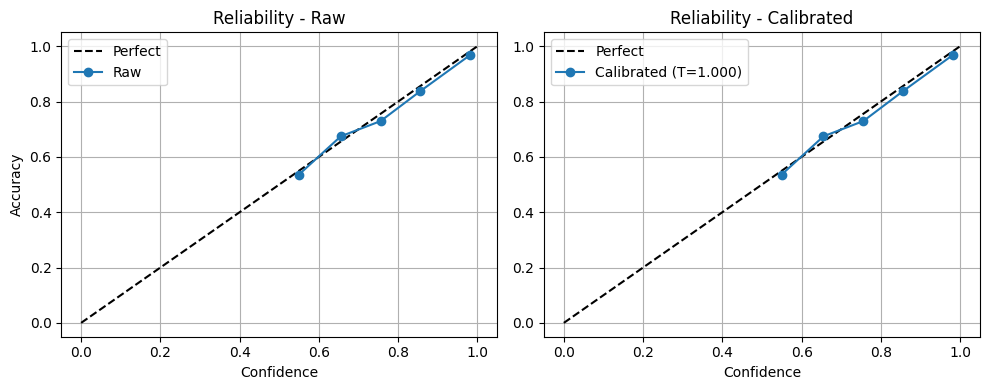

In [38]:
import matplotlib.pyplot as plt

print("Shapes:")
print("  p_val:", p_val.shape)
print("  logits_val:", logits_val.shape)
print("  y_val:", y_val.shape)
print("  p_test:", p_test.shape)
print("  logits_test:", logits_test.shape)
print("  y_test:", y_test.shape)

assert logits_val.shape[0] == y_val.shape[0], "val size mismatch"
assert logits_test.shape[0] == y_test.shape[0], "test size mismatch"

print("\nProb ranges:")
print("  p_val min/max:", p_val.min(), p_val.max())
print("  p_test min/max:", p_test.min(), p_test.max())

print("\nTemperature:", T_opt)
if not (0.01 < T_opt < 50):
    print("WARNING: Temperature is unusual — may indicate problems.")

p_test_raw = p_test
p_test_cal = probs_test_cal

y_pred_raw = np.argmax(p_test_raw, axis=1)
y_pred_cal = np.argmax(p_test_cal, axis=1)

acc_raw = np.mean(y_pred_raw == y_test)
acc_cal = np.mean(y_pred_cal == y_test)

eps = 1e-7
nll_raw = -np.mean(np.log(p_test_raw[np.arange(len(y_test)), y_test] + eps))
nll_cal = -np.mean(np.log(p_test_cal[np.arange(len(y_test)), y_test] + eps))

print("\nMetrics on TEST set:")
print(f"  Raw Accuracy:       {acc_raw:.4f}")
print(f"  Calibrated Accuracy:{acc_cal:.4f}")
print(f"  Raw NLL:            {nll_raw:.4f}")
print(f"  Calibrated NLL:     {nll_cal:.4f}")

def reliability_points_mc(y_true, probs, bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct = (predictions == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, bins + 1)
    confs, accs = [], []
    for i in range(bins):
        mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])
        if np.any(mask):
            confs.append(confidences[mask].mean())
            accs.append(correct[mask].mean())
        else:
            confs.append(np.nan)
            accs.append(np.nan)
    return np.array(confs), np.array(accs)

confs_raw, accs_raw = reliability_points_mc(y_test, p_test_raw)
confs_cal, accs_cal = reliability_points_mc(y_test, p_test_cal)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.plot(confs_raw, accs_raw, 'o-', label='Raw')
plt.title('Reliability - Raw')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.plot(confs_cal, accs_cal, 'o-', label=f'Calibrated (T={T_opt:.3f})')
plt.title('Reliability - Calibrated')
plt.xlabel('Confidence')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

### Apply Temperature Scaling

In [ ]:
from sklearn.metrics import brier_score_loss, roc_auc_score
import numpy as np

scaled_probs = 1 / (1 + np.exp(-logits_test / T_opt))
brier_scaled = brier_score_loss(y_test, scaled_probs)
auc_scaled = roc_auc_score(y_test, scaled_probs)

print(f"After calibration: Brier = {brier_scaled:.4f}, AUC = {auc_scaled:.4f}")

# Plot new reliability
reliability_diagram(y_test, scaled_probs)

NameError: name 'brier_score_loss' is not defined

### Save Model and Tokenizer

In [ ]:
SAVE_DIR = "sentiment_model_glove"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save(SAVE_DIR, include_optimizer=False)

with open(os.path.join(SAVE_DIR, "tokenizer_meta.pkl"), "wb") as f:
    pickle.dump({
        "tokenizer": tokenizer,
        "max_len": MAX_LEN,
        "temperature": T_opt
    }, f)

print("Model and tokenizer saved successfully.")

INFO:tensorflow:Assets written to: sentiment_model_glove\assets


INFO:tensorflow:Assets written to: sentiment_model_glove\assets


Model and tokenizer saved successfully.


### Quick Test

In [ ]:
sample_texts = [
    "I absolutely loved this movie!",
    "The plot was boring and predictable.",
    "This product exceeded my expectations."
]

for text in sample_texts:
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    raw_prob = model.predict(padded)[0,0]
    logit = np.log(raw_prob / (1 - raw_prob + 1e-8))
    scaled_prob = 1 / (1 + np.exp(-logit / T_opt))
    sentiment = "Positive" if scaled_prob >= 0.5 else "Negative"
    print(f"Text: {text}\n→ {sentiment} ({scaled_prob*100:.1f}%)\n")

1/1 [==============================] - 0s 312ms/step
Text: I absolutely loved this movie!
→ Positive (93.8%)

1/1 [==============================] - 0s 28ms/step
Text: The plot was boring and predictable.
→ Negative (2.1%)

1/1 [==============================] - 0s 42ms/step
Text: This product exceeded my expectations.
→ Negative (26.6%)

